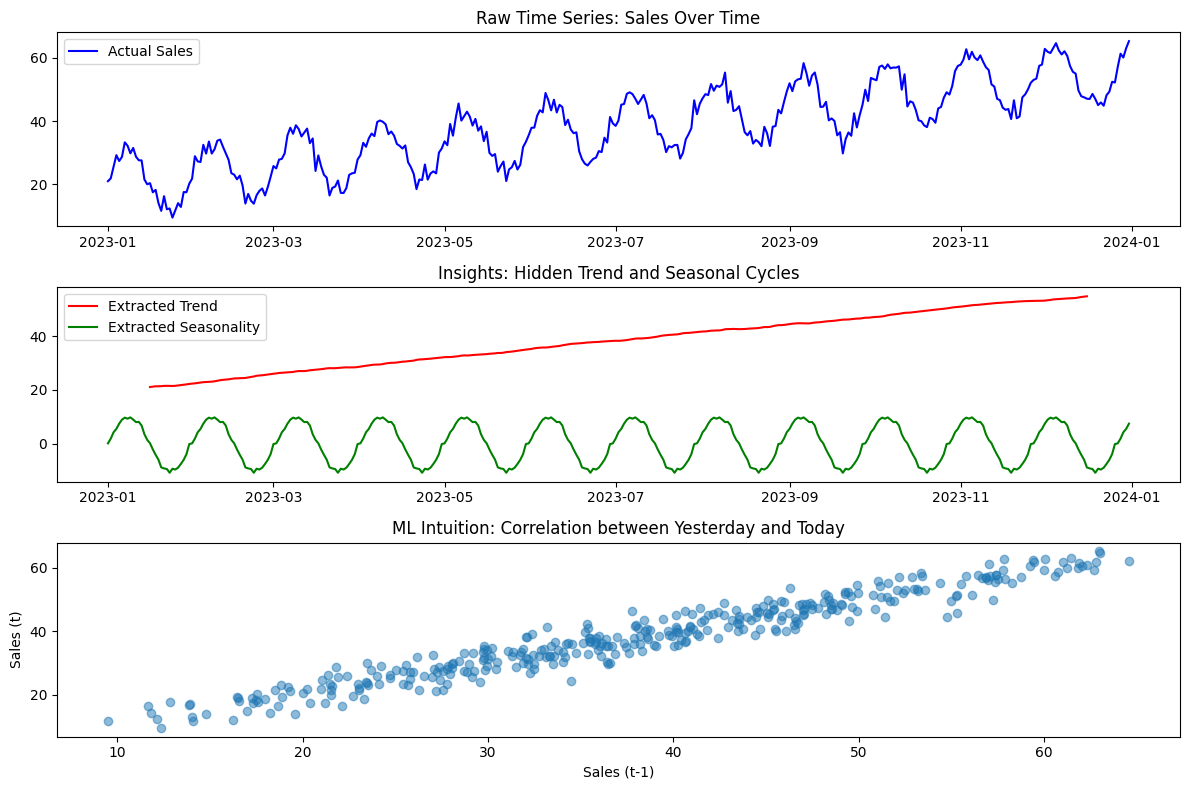

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Create Synthetic Data (1 year of daily sales)
np.random.seed(42)
time = np.arange(365)
dates = pd.date_range('2023-01-01', periods=365)

# Build components: Linear trend + Monthly sine-wave seasonality + Random noise
trend = 0.1 * time 
seasonality = 10 * np.sin(2 * np.pi * time / 30) 
noise = np.random.normal(0, 2, 365)

# Final Series
sales = 20 + trend + seasonality + noise
df = pd.DataFrame({'Date': dates, 'Sales': sales}).set_index('Date')

# Machine Learning Prep: Feature Engineering (Lags)
# We shift the data so today's model can 'see' yesterday
df['Yesterday'] = df['Sales'].shift(1)
df['Last_Week'] = df['Sales'].shift(7)

# Visualization
plt.figure(figsize=(12, 8))

# Plot A: Raw Data
plt.subplot(3, 1, 1)
plt.plot(df.index, df['Sales'], color='blue', label='Actual Sales')
plt.title('Raw Time Series: Sales Over Time')
plt.legend()

# Plot B: Decomposition
# This reveals the 'pure' trend and seasonality hidden in the noise
result = seasonal_decompose(df['Sales'], model='additive', period=30)
plt.subplot(3, 1, 2)
plt.plot(result.trend, color='red', label='Extracted Trend')
plt.plot(result.seasonal, color='green', label='Extracted Seasonality')
plt.title('Insights: Hidden Trend and Seasonal Cycles')
plt.legend()

# Plot C: ML Intuition (Lag Correlation)
plt.subplot(3, 1, 3)
plt.scatter(df['Yesterday'], df['Sales'], alpha=0.5)
plt.title('ML Intuition: Correlation between Yesterday and Today')
plt.xlabel('Sales (t-1)')
plt.ylabel('Sales (t)')

plt.tight_layout()
plt.show()

In [2]:
# visualize the data
df.describe()
df.info()
df.head(10)

<class 'pandas.DataFrame'>
DatetimeIndex: 365 entries, 2023-01-01 to 2023-12-31
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Sales      365 non-null    float64
 1   Yesterday  364 non-null    float64
 2   Last_Week  358 non-null    float64
dtypes: float64(3)
memory usage: 11.4 KB


,Sales,Yesterday,Last_Week
Date,,,
2023-01-01,20.993428,NaN,NaN
2023-01-02,21.902588,20.993428,NaN
2023-01-03,25.562744,21.902588,NaN
2023-01-04,29.223912,25.562744,NaN
2023-01-05,27.363142,29.223912,NaN
2023-01-06,28.691980,27.363142,NaN
2023-01-07,33.268991,28.691980,NaN
2023-01-08,32.180088,33.268991,20.993428
2023-01-09,29.806270,32.180088,21.902588


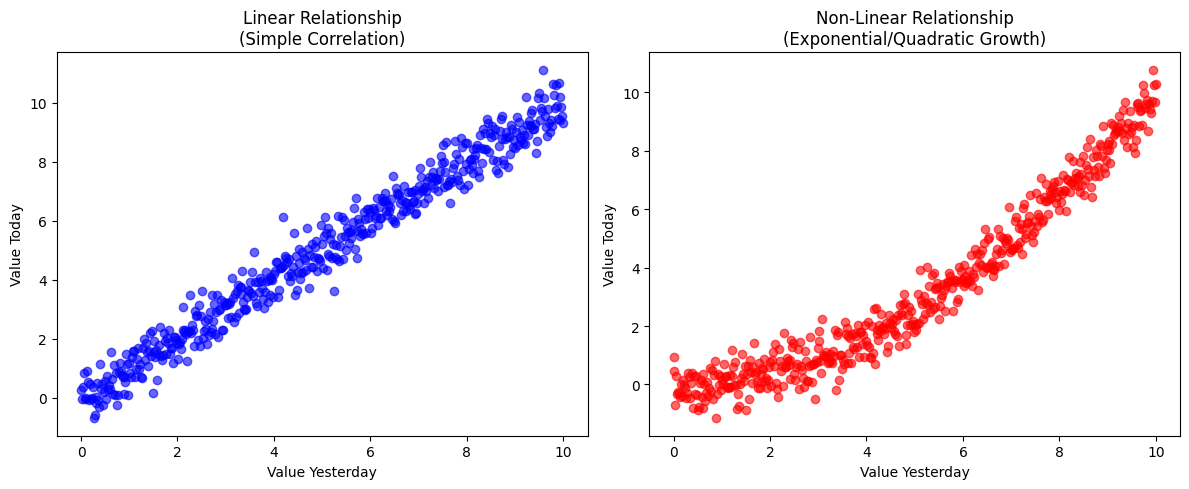

In [3]:
# visualizing non linear data

# Generate Synthetic Data
np.random.seed(42)
n_points = 500
yesterday = np.linspace(0, 10, n_points)

# Linear Relationship: Today = Yesterday + Noise
today_linear = yesterday + np.random.normal(0, 0.5, n_points)

# Non-Linear Relationship (Quadratic): Today = Yesterday^2 + Noise
# This simulates a system that accelerates rapidly
today_nonlinear = (yesterday**2) / 10 + np.random.normal(0, 0.5, n_points)

# Visualization
plt.figure(figsize=(12, 5))

# Plot 1: Linear
plt.subplot(1, 2, 1)
plt.scatter(yesterday, today_linear, alpha=0.6, color='blue')
plt.title('Linear Relationship\n(Simple Correlation)')
plt.xlabel('Value Yesterday')
plt.ylabel('Value Today')

# Plot 2: Non-Linear
plt.subplot(1, 2, 2)
plt.scatter(yesterday, today_nonlinear, alpha=0.6, color='red')
plt.title('Non-Linear Relationship\n(Exponential/Quadratic Growth)')
plt.xlabel('Value Yesterday')
plt.ylabel('Value Today')

plt.tight_layout()
plt.show()

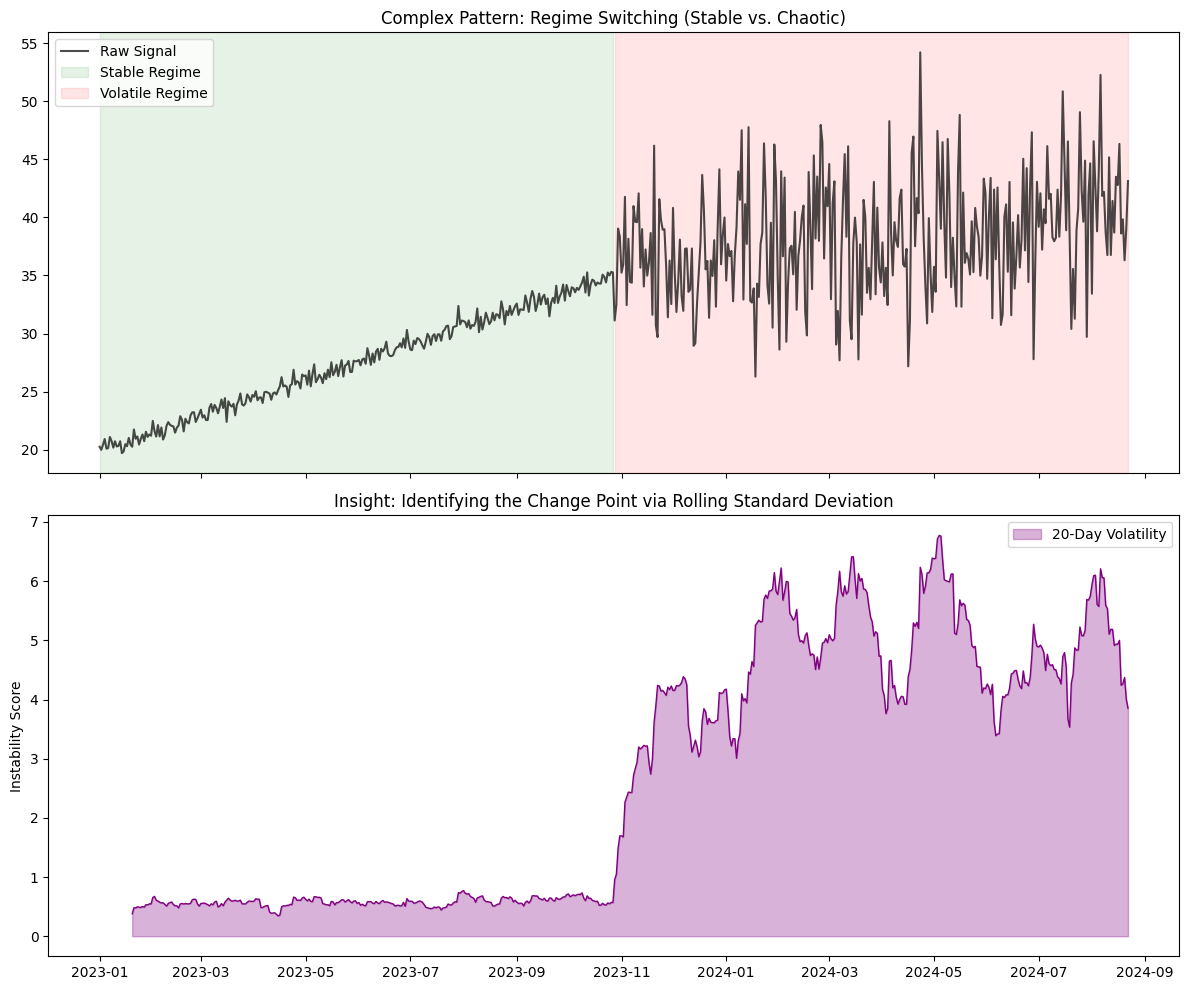

In [4]:
# some more cCOMPLEX pattern in data to see

# Create Synthetic Regime-Switching Data
np.random.seed(42)
days = 600
time = np.arange(days)

# Regime 1: Calm (Days 0-300) - Low noise, steady growth
regime1_noise = np.random.normal(0, 0.5, 300)
regime1_data = 20 + (0.05 * np.arange(300)) + regime1_noise

# Regime 2: Volatile (Days 300-600) - Huge spikes, unpredictable
regime2_noise = np.random.normal(0, 5.0, 300) # 10x more noise
regime2_data = regime1_data[-1] + (0.02 * np.arange(300)) + regime2_noise

# Combine
data = np.concatenate([regime1_data, regime2_data])
df = pd.DataFrame({'Value': data}, index=pd.date_range('2023-01-01', periods=days))

# Extract Complex Insights: Rolling Volatility
# This highlights WHERE the pattern changed
df['Rolling_Std'] = df['Value'].rolling(window=20).std()

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Top Plot: The Raw Data
ax1.plot(df.index, df['Value'], color='black', alpha=0.7, label='Raw Signal')
ax1.axvspan(df.index[0], df.index[299], color='green', alpha=0.1, label='Stable Regime')
ax1.axvspan(df.index[300], df.index[-1], color='red', alpha=0.1, label='Volatile Regime')
ax1.set_title('Complex Pattern: Regime Switching (Stable vs. Chaotic)')
ax1.legend()

# Bottom Plot: The "Hidden" Complexity (Volatility)
ax2.fill_between(df.index, df['Rolling_Std'], color='purple', alpha=0.3, label='20-Day Volatility')
ax2.plot(df.index, df['Rolling_Std'], color='purple', linewidth=1)
ax2.set_title('Insight: Identifying the Change Point via Rolling Standard Deviation')
ax2.set_ylabel('Instability Score')
ax2.legend()

plt.tight_layout()
plt.show()

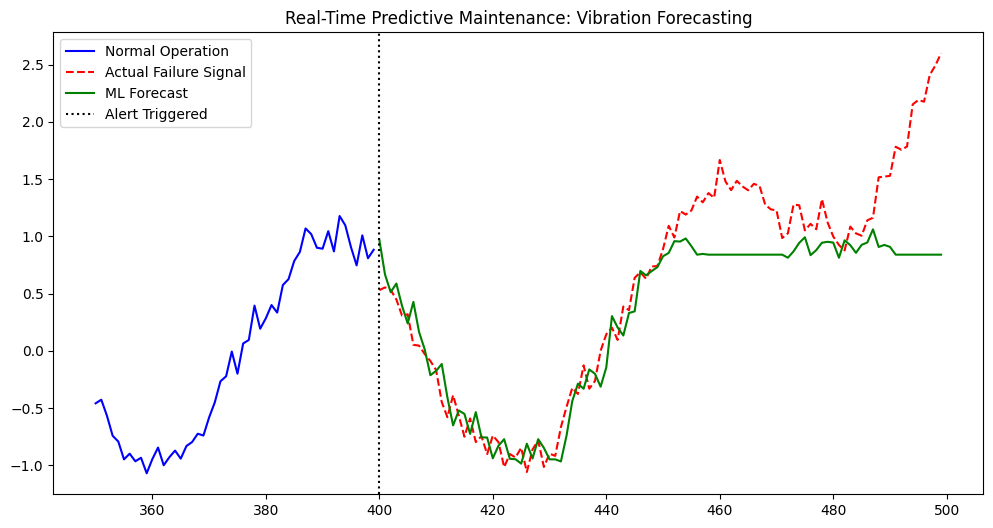

In [5]:
# REAL time scenario (forecasting) to handle time series data (synthetic) using ML models
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Simulate Sensor Data (Vibration Levels)
np.random.seed(42)
time_steps = 500
vibration = np.sin(np.linspace(0, 50, time_steps)) + np.random.normal(0, 0.1, time_steps)

# Add a "Failure" Signal (vibration starts spiked/erratic at the end)
vibration[-50:] += np.linspace(0, 3, 50) 

df = pd.DataFrame({'vibration': vibration})

# FEATURE ENGINEERING: Create "Lags" (The ML Memory)
# We teach the model: "To predict now, look at the last 3 hours"
df['lag_1'] = df['vibration'].shift(1)
df['lag_2'] = df['vibration'].shift(2)
df['lag_3'] = df['vibration'].shift(3)
df.dropna(inplace=True) # Remove rows with NaN from shifting

# Split Data: Train on "Normal" data, Test on the "Failure" period
train = df.iloc[:-100]
test = df.iloc[-100:]

X_train, y_train = train[['lag_1', 'lag_2', 'lag_3']], train['vibration']
X_test, y_test = test[['lag_1', 'lag_2', 'lag_3']], test['vibration']

# Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and Visualize
predictions = model.predict(X_test)

plt.figure(figsize=(12, 6))
plt.plot(df.index[-150:-100], df['vibration'][-150:-100], label='Normal Operation', color='blue')
plt.plot(test.index, y_test, label='Actual Failure Signal', color='red', linestyle='--')
plt.plot(test.index, predictions, label='ML Forecast', color='green')
plt.axvline(x=400, color='black', linestyle=':', label='Alert Triggered')
plt.title('Real-Time Predictive Maintenance: Vibration Forecasting')
plt.legend()
plt.show()

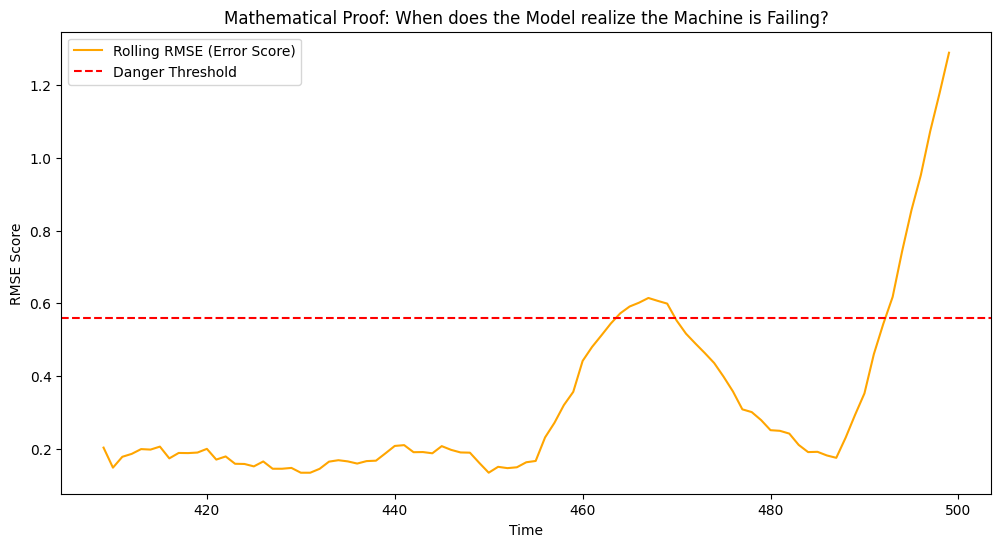

Alert: Machine anomaly detected at index 464!


In [6]:
# ERROR score
from sklearn.metrics import mean_squared_error

# (Continuing from previous pump failure data)
# 'y_test' is the actual vibrating sensor
# 'predictions' is what the ML model expected to happen

# Calculate Squared Error for every single point
# Error = (Actual - Predicted)^2
individual_errors = (y_test - predictions)**2

# Calculate "Rolling RMSE" (Root Mean Squared Error)
# We look at the last 10 points to see if the error is consistently rising
rolling_rmse = np.sqrt(pd.Series(individual_errors).rolling(window=10).mean())

# Define a "Danger Threshold" 
# If the error is 3x higher than normal, the machine is failing
threshold = rolling_rmse.iloc[:20].mean() * 3 

# Visualization
plt.figure(figsize=(12, 6))

# Plot 1: The Error Score
plt.plot(test.index, rolling_rmse, color='orange', label='Rolling RMSE (Error Score)')
plt.axhline(y=threshold, color='red', linestyle='--', label='Danger Threshold')

# Find the exact moment of failure
failure_moment = rolling_rmse[rolling_rmse > threshold].index[0]
#plt.axvline(x=failure_moment, color='black', label=f'Failure Detected at {failure_moment.time()}')

plt.title('Mathematical Proof: When does the Model realize the Machine is Failing?')
plt.ylabel('RMSE Score')
plt.xlabel('Time')
plt.legend()
plt.show()

print(f"Alert: Machine anomaly detected at index {failure_moment}!")

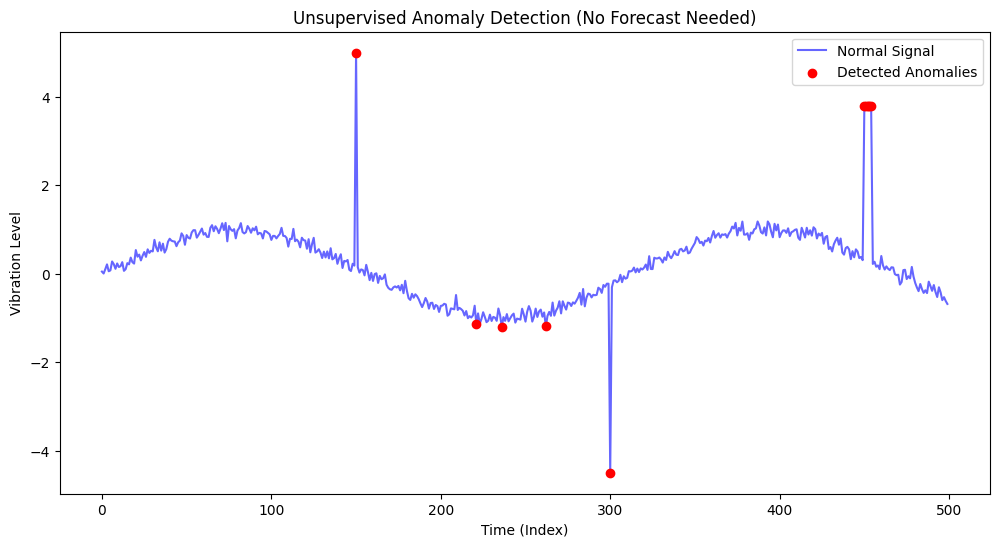

Detected 10 anomalous data points.


In [7]:
# ANOMALY detection
from sklearn.ensemble import IsolationForest

# Generate Data (Normal Waves + Random Sudden Spikes)
np.random.seed(42)
time = np.linspace(0, 10, 500)
vibration = np.sin(time) + np.random.normal(0, 0.1, 500)

# Inject random "Anomalies" (Sudden spikes that aren't failures yet)
vibration[150] = 5.0
vibration[300] = -4.5
vibration[450:455] = 3.8 # A short burst of trouble

df = pd.DataFrame({'vibration': vibration})

# Setup the Anomaly Detection Layer
# contamination=0.02 means we expect about 2% of data to be "weird"
model = IsolationForest(contamination=0.02, random_state=42)

# Fit and Predict
# -1 indicates an anomaly, 1 indicates normal
df['anomaly_score'] = model.fit_predict(df[['vibration']])
df['is_anomaly'] = df['anomaly_score'].map({1: False, -1: True})

# Visualization
plt.figure(figsize=(12, 6))

# Plot the normal data
plt.plot(df.index, df['vibration'], color='blue', label='Normal Signal', alpha=0.6)

# Overlay the detected anomalies in red
anomalies = df[df['is_anomaly'] == True]
plt.scatter(anomalies.index, anomalies['vibration'], color='red', label='Detected Anomalies', zorder=5)

plt.title('Unsupervised Anomaly Detection (No Forecast Needed)')
plt.xlabel('Time (Index)')
plt.ylabel('Vibration Level')
plt.legend()
plt.show()

print(f"Detected {len(anomalies)} anomalous data points.")

C:\python\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


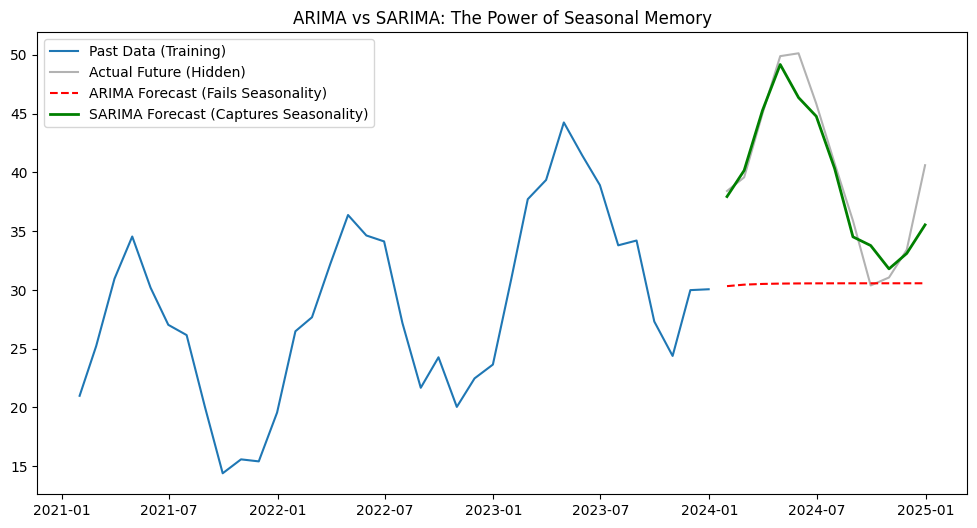

In [10]:
# ARIMA/SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

# Generate Synthetic Monthly Data (3 years)
np.random.seed(42)
months = pd.date_range('2021-01-01', periods=48, freq='ME')
trend = 0.5 * np.arange(48) # Steady growth
seasonality = 10 * np.sin(2 * np.pi * np.arange(48) / 12) # Yearly cycle
noise = np.random.normal(0, 2, 48)
data = 20 + trend + seasonality + noise

df = pd.DataFrame({'Sales': data}, index=months)

# Split into Train (3 years) and Test (1 year)
train = df.iloc[:-12]
test = df.iloc[-12:]

# Fit ARIMA (Ignores Seasonality)
# Order: (1 lag, 1 difference, 1 error window)
model_arima = ARIMA(train['Sales'], order=(1, 1, 1))
res_arima = model_arima.fit()
forecast_arima = res_arima.forecast(steps=12)

# Fit SARIMA (Captures Seasonality)
# Seasonal Order: (1, 1, 1, 12) -> 12 means monthly cycle
model_sarima = SARIMAX(train['Sales'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
res_sarima = model_sarima.fit(disp=False)
forecast_sarima = res_sarima.get_forecast(steps=12).summary_frame()['mean']

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Sales'], label='Past Data (Training)')
plt.plot(test.index, test['Sales'], label='Actual Future (Hidden)', color='black', alpha=0.3)
plt.plot(test.index, forecast_arima, label='ARIMA Forecast (Fails Seasonality)', color='red', linestyle='--')
plt.plot(test.index, forecast_sarima, label='SARIMA Forecast (Captures Seasonality)', color='green', linewidth=2)

plt.title('ARIMA vs SARIMA: The Power of Seasonal Memory')
plt.legend()
plt.show()

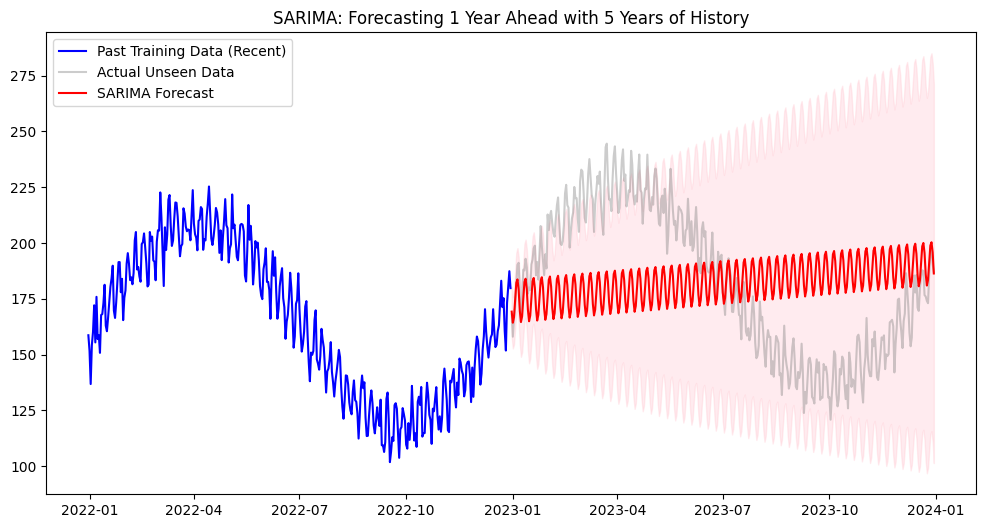

In [11]:
# EXPLORE on MORE data
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Generate 5 Years of Daily Data (~1825 points)
np.random.seed(42)
dates = pd.date_range(start='2019-01-01', periods=1825, freq='D')

# Components: Upward Trend + Weekly (7 days) + Yearly (365 days)
trend = 0.05 * np.arange(1825)
weekly = 10 * np.sin(2 * np.pi * np.arange(1825) / 7)
yearly = 50 * np.sin(2 * np.pi * np.arange(1825) / 365)
noise = np.random.normal(0, 5, 1825)

data = 100 + trend + weekly + yearly + noise
df = pd.DataFrame({'Sales': data}, index=dates)

# Split Data: Train on first 4 years, Test on the last year
train = df.iloc[:-365]
test = df.iloc[-365:]

# Fit SARIMA Model
# Note: We use s=7 (weekly) as modelling s=365 is computationally very slow.
# Order (p,d,q) and Seasonal Order (P,D,Q,s)
model = SARIMAX(train['Sales'], 
                order=(1, 1, 1), 
                seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)

# 4. Forecast the Next 365 Days
forecast_obj = results.get_forecast(steps=365)
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# 5. Visualization
plt.figure(figsize=(12, 6))
plt.plot(train.index[-365:], train['Sales'][-365:], label='Past Training Data (Recent)', color='blue')
plt.plot(test.index, test['Sales'], label='Actual Unseen Data', color='gray', alpha=0.4)
plt.plot(test.index, forecast_mean, label='SARIMA Forecast', color='red')
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('SARIMA: Forecasting 1 Year Ahead with 5 Years of History')
plt.legend()
plt.show()